# PM2.5 Extreme Event Analysis
This notebook analyzes extreme PM2.5 pollution events and evaluates
model performance during high-pollution episodes.
**Objectives**
- Identify extreme pollution days
- Quantify frequency and severity
- Compare model performance on normal vs extreme days
- Understand forecasting limitations during spikes

## Data & Model Context
- Target Variable: PM2.5
- Forecast Model: SARIMA / Seasonal ARIMA
- Train Period: 2020–2022
- Test Period: 2023
- City-level time series analysis

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
df = pd.read_csv("../results/PM25_SARIMA_forecast_daily.csv", parse_dates=["Date"])
df.head()

,Date,City,Actual_PM25,Forecast_PM25
0,2023-01-01,Montréal,3.791667,7.617046
1,2023-01-02,Montréal,8.791667,7.076527
2,2023-01-03,Montréal,10.166667,7.060252
3,2023-01-04,Montréal,5.208333,6.638644
4,2023-01-05,Montréal,7.875000,7.349447


In [9]:
threshold = df["Actual_PM25"].quantile(0.95)
print("Extreme threshold:", round(threshold,2))

Extreme threshold: 29.98


In [11]:
df["Extreme"] = df["Actual_PM25"] > threshold
df["Abs_Error"] = abs(df["Actual_PM25"] - df["Forecast_PM25"])
df.head()

,Date,City,Actual_PM25,Forecast_PM25,Extreme,Abs_Error
0,2023-01-01,Montréal,3.791667,7.617046,False,3.825379
1,2023-01-02,Montréal,8.791667,7.076527,False,1.715140
2,2023-01-03,Montréal,10.166667,7.060252,False,3.106415
3,2023-01-04,Montréal,5.208333,6.638644,False,1.430311
4,2023-01-05,Montréal,7.875000,7.349447,False,0.525553


In [13]:
total_days = len(df)
extreme_days = df["Extreme"].sum()
print("Total days:", total_days)
print("Extreme days:", extreme_days)
print("Extreme %:", round(extreme_days/total_days*100,2), "%")

Total days: 3650
Extreme days: 183
Extreme %: 5.01 %


In [15]:
extreme_df = df[df["Extreme"]]
print("Average PM2.5 on extreme days:", round(extreme_df["Actual_PM25"].mean(),2))
print("Maximum PM2.5:", round(extreme_df["Actual_PM25"].max(),2))

Average PM2.5 on extreme days: 71.86
Maximum PM2.5: 354.62


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

normal_df = df[~df["Extreme"]]

mae_n, rmse_n, r2_n = metrics(normal_df["Actual_PM25"], normal_df["Forecast_PM25"])
mae_e, rmse_e, r2_e = metrics(extreme_df["Actual_PM25"], extreme_df["Forecast_PM25"])

print("NORMAL DAYS → MAE:", round(mae_n,2), "RMSE:", round(rmse_n,2), "R2:", round(r2_n,3))
print("EXTREME DAYS → MAE:", round(mae_e,2), "RMSE:", round(rmse_e,2), "R2:", round(r2_e,3))

NORMAL DAYS → MAE: 3.75 RMSE: 5.16 R2: 0.048
EXTREME DAYS → MAE: 63.86 RMSE: 84.71 R2: -1.334


In [19]:
top_miss = df.sort_values("Abs_Error", ascending=False).head(10)
top_miss[["Date","City","Actual_PM25","Forecast_PM25","Abs_Error"]]

,Date,City,Actual_PM25,Forecast_PM25,Abs_Error
2695,2023-05-21,Fort Mckay,354.625000,5.629736,348.995264
869,2023-05-20,Edmonton,322.416667,11.643310,310.773356
2799,2023-09-02,Fort Mckay,311.500000,6.186553,305.313447
2749,2023-07-14,Fort Mckay,283.833333,5.634459,278.198875
2800,2023-09-03,Fort Mckay,265.833333,5.760725,260.072608
870,2023-05-21,Edmonton,258.333333,10.818428,247.514906
2748,2023-07-13,Fort Mckay,218.666667,6.315905,212.350761
2717,2023-06-12,Fort Mckay,206.041667,6.006216,200.035451
925,2023-07-15,Edmonton,202.208333,11.799753,190.408580
2707,2023-06-02,Fort Mckay,169.958333,5.582063,164.376270


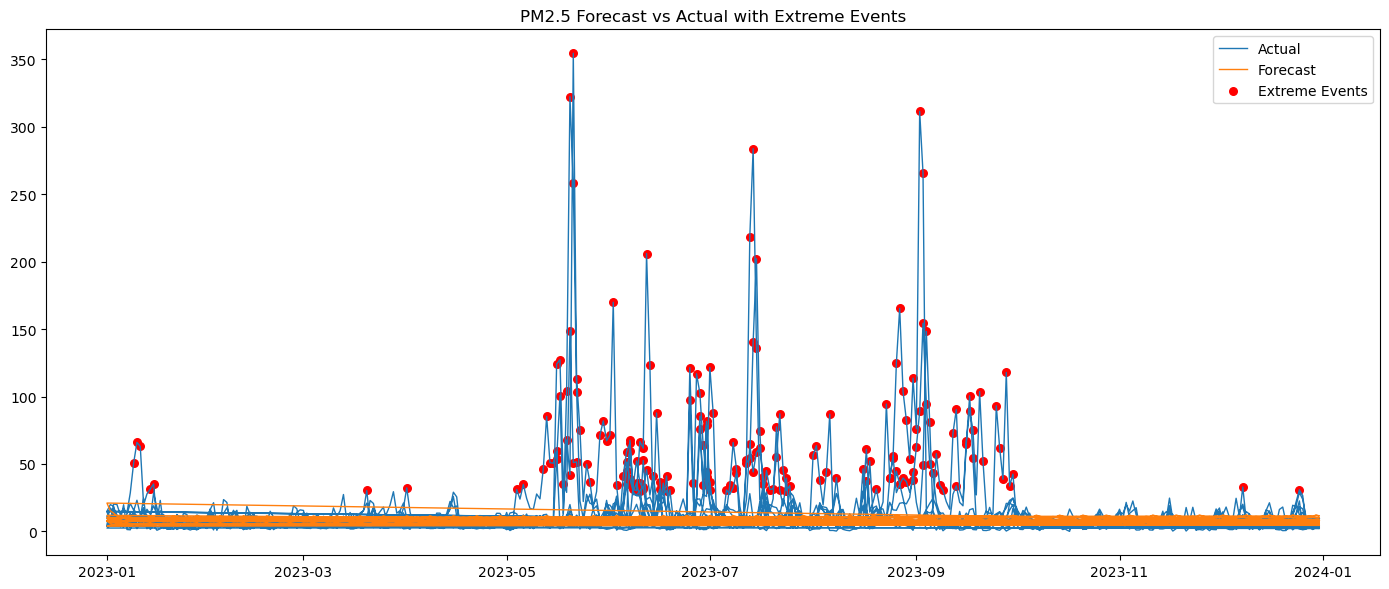

In [21]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Actual_PM25"], label="Actual", linewidth=1)
plt.plot(df["Date"], df["Forecast_PM25"], label="Forecast", linewidth=1)

plt.scatter(extreme_df["Date"], extreme_df["Actual_PM25"],
            color="red", label="Extreme Events", s=30)

plt.title("PM2.5 Forecast vs Actual with Extreme Events")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
print("===== EXTREME EVENT SUMMARY =====")
print("Total days:", len(df))
print("Extreme days:", df["Extreme"].sum())
print("Extreme %:", round(df["Extreme"].mean()*100, 2), "%")
print()
print("Average PM2.5 on extreme days:", round(extreme_df["Actual_PM25"].mean(),2))
print("Max PM2.5:", round(extreme_df["Actual_PM25"].max(),2))
print()
print("NORMAL DAYS PERFORMANCE")
print("MAE:", round(mae_n,2), "RMSE:", round(rmse_n,2), "R2:", round(r2_n,3))
print()
print("EXTREME DAYS PERFORMANCE")
print("MAE:", round(mae_e,2), "RMSE:", round(rmse_e,2), "R2:", round(r2_e,3))

===== EXTREME EVENT SUMMARY =====
Total days: 3650
Extreme days: 183
Extreme %: 5.01 %

Average PM2.5 on extreme days: 71.86
Max PM2.5: 354.62

NORMAL DAYS PERFORMANCE
MAE: 3.75 RMSE: 5.16 R2: 0.048

EXTREME DAYS PERFORMANCE
MAE: 63.86 RMSE: 84.71 R2: -1.334


In [27]:
extreme_df.to_csv("../results/PM25_Extreme_Events.csv", index=False)
print("Saved: ../results/PM25_Extreme_Events.csv")

Saved: ../results/PM25_Extreme_Events.csv


In [29]:
summary_df = pd.DataFrame({
    "Metric": [
        "Total Days", "Extreme Days", "Extreme %",
        "Average PM2.5 on Extreme Days", "Max PM2.5",
        "Normal Days MAE", "Normal Days RMSE", "Normal Days R2",
        "Extreme Days MAE", "Extreme Days RMSE", "Extreme Days R2"
    ],
    "Value": [
        len(df),
        df["Extreme"].sum(),
        round(df["Extreme"].mean()*100, 2),
        round(extreme_df["Actual_PM25"].mean(), 2),
        round(extreme_df["Actual_PM25"].max(), 2),
        round(mae_n, 2),
        round(rmse_n, 2),
        round(r2_n, 3),
        round(mae_e, 2),
        round(rmse_e, 2),
        round(r2_e, 3)
    ]
})

summary_df.to_csv("../results/PM25_extreme_event_summary.csv", index=False)
print("Saved: ../results/PM25_extreme_event_summary.csv")

Saved: ../results/PM25_extreme_event_summary.csv
